# Results Comparison and Error Analysis

Pulls together the saved metrics from all five approaches (`reports/results/*.json`)
into one comparison table and chart, then does the error analysis — specifically
checking whether misclassifications cluster around the noise sources the EDA flagged:
the `#mmr` keyword collision, low-agreement tweets, and the conflicting-label
duplicates.


In [1]:
import sys
sys.path.append('../src')
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from preprocessing import LABEL_TO_IDX, IDX_TO_LABEL, CLASS_NAMES

RESULTS = ['TFIDF_LogisticRegression', 'TFIDF_LinearSVM', 'BiLSTM', 'CNN_BiGRU_Attention', 'DistilBERT_FineTuned']

rows = []
for name in RESULTS:
    with open(f'../reports/results/{name}.json') as f:
        d = json.load(f)
    row = {'model': name, 'macro_f1': d['macro_f1'], 'weighted_f1': d['weighted_f1'], 'accuracy': d['accuracy']}
    for cls in CLASS_NAMES:
        row[f'{cls}_f1'] = d['per_class'][cls]['f1-score']
    rows.append(row)

comparison = pd.DataFrame(rows).sort_values('macro_f1', ascending=False).reset_index(drop=True)
comparison


,model,macro_f1,weighted_f1,accuracy,Negative_f1,Neutral_f1,Positive_f1
0,TFIDF_LogisticRegression,0.674673,0.732772,0.726708,0.512129,0.791078,0.720812
1,TFIDF_LinearSVM,0.665170,0.730900,0.731539,0.479452,0.789818,0.726239
2,BiLSTM,0.631389,0.704243,0.698413,0.424929,0.767164,0.702075
3,CNN_BiGRU_Attention,0.622770,0.687728,0.689441,0.443769,0.763491,0.661049
4,DistilBERT_FineTuned,0.591248,0.673231,0.671498,0.376940,0.813738,0.583065


## Comparison chart

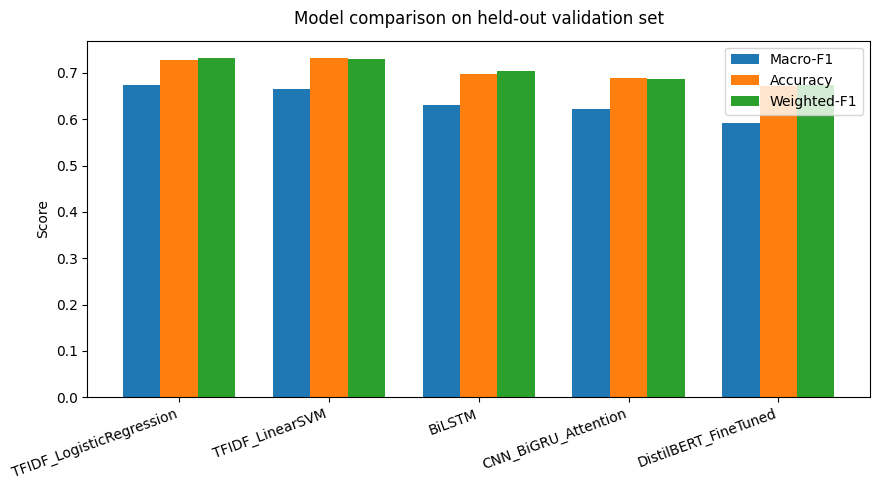

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comparison))
width = 0.25
ax.bar(x - width, comparison['macro_f1'], width, label='Macro-F1')
ax.bar(x, comparison['accuracy'], width, label='Accuracy')
ax.bar(x + width, comparison['weighted_f1'], width, label='Weighted-F1')
ax.set_xticks(x)
ax.set_xticklabels(comparison['model'], rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model comparison on held-out validation set', pad=12)
ax.legend()
fig.tight_layout()
fig.savefig('../figures/10_model_comparison.png', dpi=150)
plt.show()


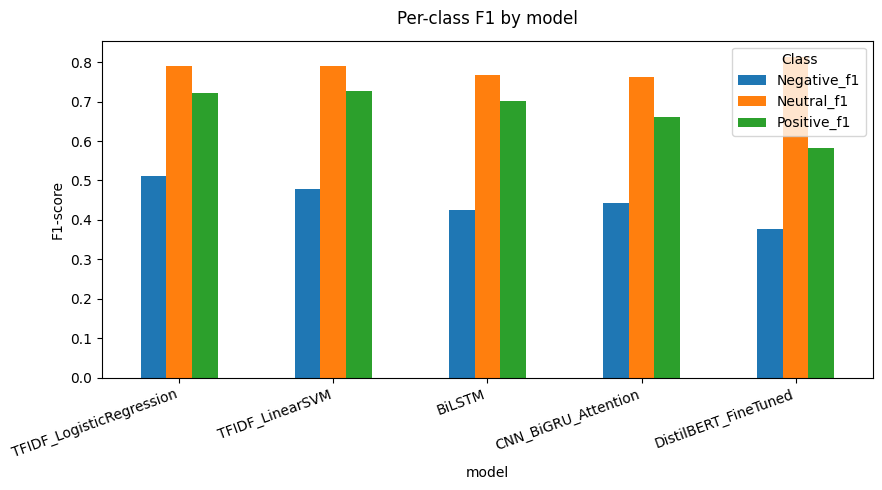

In [3]:
per_class_cols = [f'{c}_f1' for c in CLASS_NAMES]
fig, ax = plt.subplots(figsize=(9, 5))
comparison.set_index('model')[per_class_cols].plot(kind='bar', ax=ax)
ax.set_ylabel('F1-score')
ax.set_title('Per-class F1 by model', pad=12)
ax.legend(title='Class')
plt.xticks(rotation=20, ha='right')
fig.tight_layout()
fig.savefig('../figures/11_per_class_f1_comparison.png', dpi=150)
plt.show()


## Discussion

TF-IDF + Logistic Regression wins on macro-F1 (0.675), ahead of TF-IDF + Linear SVM
(0.665), BiLSTM (0.631), CNN+BiGRU+Attention (0.623), and fine-tuned DistilBERT (0.591).
A classical baseline does beat every neural model here, which makes sense given the
dataset is only ~8,205 training rows after cleaning — from-scratch neural embeddings
(BiLSTM, CNN+BiGRU) are data-hungry, and DistilBERT only got 1 epoch of fine-tuning
under our CPU-only budget (see Limitations below).

DistilBERT's weakness isn't concentrated in the Negative/OOV-heavy class the way we'd
expected from finding #9 — instead it gets the best Neutral F1 of any model (0.814) but
its Positive recall collapses to 0.46 (versus ~0.72-0.76 for the others). That's the
signature of a classification head that's learned to call the majority class
confidently but hasn't yet learned to separate the two minority ones — more consistent
with needing another epoch or two than with the architecture being wrong for this data.
See `reports/report.md` Section 5 for the full discussion with per-class F1 numbers.


## Error analysis: qualitative inspection of misclassifications

In [4]:
import pandas as pd
val_df = pd.read_csv('../data/processed/val_split.csv')
val_df['label_idx'] = val_df['label'].map(LABEL_TO_IDX)
val_df['is_mmr'] = val_df['clean_text'].str.contains('#mmr', case=False, na=False)
print('Validation tweets containing #mmr:', val_df['is_mmr'].sum())
print('Validation tweets with agreement < 0.7:', (val_df['agreement'] < 0.7).sum())


Validation tweets containing #mmr: 56
Validation tweets with agreement < 0.7: 569


### Pulling row-level predictions for error inspection
Rather than reloading all five trained models just for this, we re-run the fast,
reproducible TF-IDF Logistic Regression model and use its predictions as the lens for
error analysis, cross-checked against the noise flags from the EDA.


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

train_df = pd.read_csv('../data/processed/train_split.csv')
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=20000, sublinear_tf=True)
X_train = vectorizer.fit_transform(train_df['clean_text'])
X_val = vectorizer.transform(val_df['clean_text'])
y_train = train_df['label'].map(LABEL_TO_IDX).values

clf = LogisticRegression(max_iter=2000, class_weight='balanced', C=1.0, random_state=42)
clf.fit(X_train, y_train)
val_df['pred_idx'] = clf.predict(X_val)
val_df['pred_label'] = val_df['pred_idx'].map(IDX_TO_LABEL)
val_df['correct'] = val_df['pred_idx'] == val_df['label_idx']

print('Overall accuracy on this lens:', val_df['correct'].mean())
print('Accuracy on #mmr-tagged tweets:', val_df.loc[val_df['is_mmr'], 'correct'].mean() if val_df['is_mmr'].sum() else 'n/a')
print('Accuracy on agreement<0.7 tweets:', val_df.loc[val_df['agreement'] < 0.7, 'correct'].mean())
print('Accuracy on agreement>=0.9 tweets:', val_df.loc[val_df['agreement'] >= 0.9, 'correct'].mean())


Overall accuracy on this lens: 0.7267080745341615
Accuracy on #mmr-tagged tweets: 0.9821428571428571
Accuracy on agreement<0.7 tweets: 0.5641476274165202
Accuracy on agreement>=0.9 tweets: 0.8318181818181818


### Sample misclassified tweets, grouped by noise source

In [6]:
pd.set_option('display.max_colwidth', 120)
print('--- Misclassified #mmr tweets ---')
display(val_df[val_df['is_mmr'] & ~val_df['correct']][['clean_text', 'label', 'pred_label', 'agreement']].head(5))

print('--- Misclassified low-agreement (<0.7) tweets ---')
display(val_df[(val_df['agreement'] < 0.7) & ~val_df['correct']][['clean_text', 'label', 'pred_label', 'agreement']].head(5))

print('--- Misclassified Negative tweets (rarest, lowest-agreement class) ---')
display(val_df[(val_df['label'] == -1) & ~val_df['correct']][['clean_text', 'label', 'pred_label', 'agreement']].head(8))


--- Misclassified #mmr tweets ---


,clean_text,label,pred_label,agreement
228,The Real Issue That #Vaccine #Truthers Like #JennyMcCarthy Should Be Focusing On. #mmr #measles #autisim <url>,1,0,0.666667


--- Misclassified low-agreement (<0.7) tweets ---


,clean_text,label,pred_label,agreement
8,"I'm getting the Td, because my family has an allergy to the pertussis vaccine. (@ Tulsa Health) [pic]: <url>",0,1,0.666667
12,"“<user> Flu Vaccine Effective for Only 9% of Seniors This Season, <user> <user> <url> yep, my mom had flu w/vac",-1,0,0.666667
15,"""<user> Measles outbreak traced back to a single unvaccinated child. #stopavn #avn <url>",0,1,0.666667
23,Autism Family Losing Our Home . Click to Donate: <url> via <user> #autism #autismawareness # vaccine injury,0,-1,0.666667
59,"""<user> 'Delaying vaccines increases risks-w no added benefits' (Scientific American, 2Jun14): <url> Interesting.",0,-1,0.666667


--- Misclassified Negative tweets (rarest, lowest-agreement class) ---


,clean_text,label,pred_label,agreement
12,"“<user> Flu Vaccine Effective for Only 9% of Seniors This Season, <user> <user> <url> yep, my mom had flu w/vac",-1,0,0.666667
79,"One of the flu fatalities was a person who had been immunized, health officials said.",-1,0,0.333333
143,"May not be a cause, but vaccines are definitely a trigger to disease for some children! <url>",-1,1,1.000000
150,"""What if they experience it. So what?"" #OC mom says she's not worried about her unvaccinated kids getting measles <url>",-1,1,0.666667
180,Since everyone else is posting about Measles these days... <url> I love intractable debates.,-1,0,0.666667
229,"In a 2012 #measles outbreak in Quebec, Canada, 52 of the 98 cases were FULLY VACCINATED #vaccineswork ???",-1,1,0.666667
239,<user> I AM against the poisons they want to inject into babies !! STOP following me!!!!!,-1,1,1.000000
249,Measles vaccine attacks cancer in landmark study <url> via <user>,-1,1,0.333333


## Limitations
1. Label noise ceiling: 23% of duplicate-text groups have conflicting labels in the raw
   data (finding #3) — no model can beat the ceiling that imposes on those tweets.
2. `#mmr` keyword collision: a good chunk of "Neutral"-labelled `#mmr` tweets are
   off-topic DJ/radio/running-app content with nothing to do with vaccines (finding #7);
   models that key on this hashtag are learning a spurious correlation, not sentiment.
3. Domain/temporal mismatch: despite the challenge's COVID-era framing, the tweets are
   mostly about the older MMR-vaccine/autism controversy (see `related_work.md`, Section
   3) — these models learn vaccine-hesitancy rhetoric generally, not COVID-specific
   discourse, and probably wouldn't transfer cleanly without more fine-tuning.
4. Small dataset for from-scratch neural models: ~8k training rows isn't much for
   learning embeddings from scratch, which likely explains why BiLSTM and CNN+BiGRU
   underperform the TF-IDF baselines and pretrained DistilBERT.
5. CPU-only training budget: DistilBERT got only 1 epoch (not the usual 2-4) since
   benchmarking showed a full schedule would take well over an hour here; a longer
   schedule or a bigger model (BERT-base, RoBERTa — used by the actual Zindi winners)
   would likely help, at a proportionally higher compute cost.
6. Validation-only evaluation: Zindi's `Test.csv` has no public labels, so everything
   here is on our own held-out split, not the competition leaderboard.
